In [53]:
import numpy as np
import pandas as pd
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima 

In [54]:
df = pd.read_excel(
    "/home/henrique/ic-rodrigo/Controle_Faturamento_2023.xlsx",
    sheet_name="Consumo Médio - Clientes",
)

df.drop(df.iloc[:, 48:68], inplace=True, axis=1)
df.drop("Nº Cliente", inplace=True, axis=1)
df.drop("Cliente", inplace=True, axis=1)

df = df.head()

df1 = df.transpose()
df = df1.rename(columns=df1.iloc[0])
df.drop("UC", inplace=True, axis=0)
df.dropna(inplace=True)

df.index
dates = np.array(df.index, dtype="datetime64[D]")
idx = pd.DatetimeIndex(dates)
df["idx"] = idx
df.set_index("idx", inplace=True)
df.index.freq = "MS"
df

,3003858507,3001084033,3011373971,3001449459,3011504476
idx,,,,,
2019-06-01,1246.0,7160.0,440.0,960.0,1560.0
2019-07-01,1081.0,6520.0,600.0,920.0,1280.0
2019-08-01,1184.0,6840.0,680.0,1120.0,1360.0
2019-09-01,1549.0,7440.0,760.0,1040.0,1680.0
2019-10-01,2045.0,6920.0,560.0,1120.0,1680.0
2019-11-01,4017.0,6920.0,520.0,1240.0,2920.0
2019-12-01,2386.0,7240.0,320.0,1000.0,1960.0
2020-01-01,4239.0,6560.0,440.0,1120.0,2280.0
2020-02-01,2854.0,7440.0,280.0,1200.0,2480.0


In [55]:
df[3003858507].iloc[3:5] = np.nan
df[3003858507].iloc[17] = np.nan
df[3003858507].iloc[23:25] = np.nan
df[3003858507].iloc[41] = np.nan
df

,3003858507,3001084033,3011373971,3001449459,3011504476
idx,,,,,
2019-06-01,1246.0,7160.0,440.0,960.0,1560.0
2019-07-01,1081.0,6520.0,600.0,920.0,1280.0
2019-08-01,1184.0,6840.0,680.0,1120.0,1360.0
2019-09-01,NaN,7440.0,760.0,1040.0,1680.0
2019-10-01,NaN,6920.0,560.0,1120.0,1680.0
2019-11-01,4017.0,6920.0,520.0,1240.0,2920.0
2019-12-01,2386.0,7240.0,320.0,1000.0,1960.0
2020-01-01,4239.0,6560.0,440.0,1120.0,2280.0
2020-02-01,2854.0,7440.0,280.0,1200.0,2480.0


In [56]:
df[3003858507] = df[3003858507].fillna(method="backfill", axis=None)

[Text(0.5, 0, ''), Text(0, 0.5, 'Consumo')]

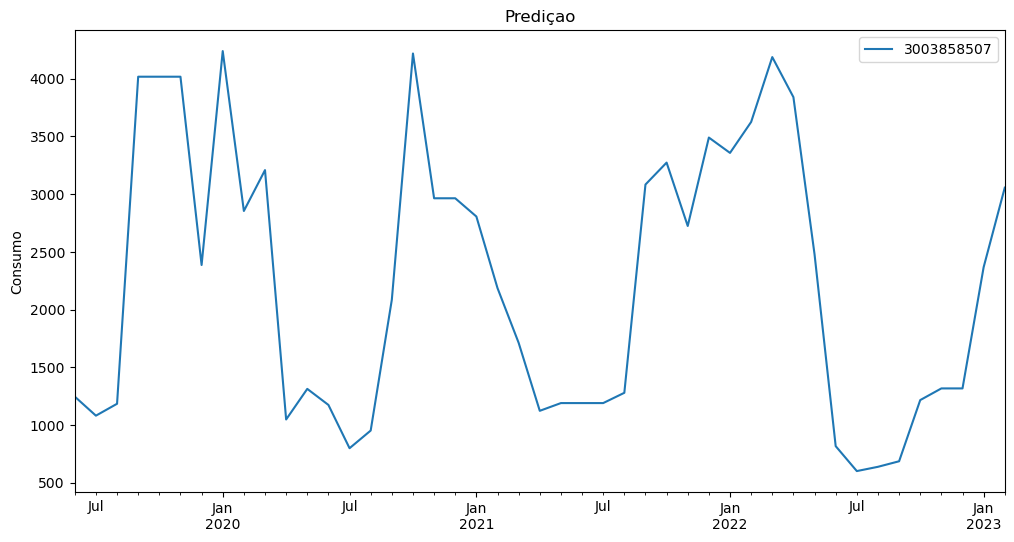

In [57]:
title = "Prediçao"
ylabel = "Consumo"
xlabel = ""

ax = df[3003858507].plot(legend=True, figsize=(12, 6), title=title)
ax.autoscale(axis="x", tight=True)
ax.set(xlabel=xlabel, ylabel=ylabel)

In [58]:
train = df.iloc[:40]
test = df.iloc[40:]

test = test.astype(float)
train = train.astype(float)

model = SARIMAX(df[3003858507].astype(float), order=(1, 0, 0), seasonal_order=(5, 1, 7, 12))
results = model.fit();

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           14     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  6.08413D+00    |proj g|=  2.76607D-01


 This problem is unconstrained.



At iterate    5    f=  5.99682D+00    |proj g|=  1.46183D-02

At iterate   10    f=  5.99591D+00    |proj g|=  7.99070D-04

At iterate   15    f=  5.99586D+00    |proj g|=  3.89454D-04

At iterate   20    f=  5.99583D+00    |proj g|=  3.27276D-03

At iterate   25    f=  5.99576D+00    |proj g|=  2.53930D-04

At iterate   30    f=  5.99574D+00    |proj g|=  2.29169D-03

At iterate   35    f=  5.99433D+00    |proj g|=  1.62877D-02

At iterate   40    f=  5.98871D+00    |proj g|=  2.63823D-02

At iterate   45    f=  5.96578D+00    |proj g|=  3.71058D-01
  ys=-2.195E-02  -gs= 1.196E-02 BFGS update SKIPPED

At iterate   50    f=  5.95786D+00    |proj g|=  1.64907D-02

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final 

In [59]:
start = len(train)
end = len(train) + len(test) - 1
predictions = results.predict(
    start=0, end=end, dynamic=False, typ="levels"
).rename("SARIMA Predictions")

future_predictions = results.predict(
    start=end, end=end + 24, dynamic=False, typ="levels"
).rename("SARIMA Future Predictions")

for i in range(len(predictions)):
    print(
        f"predição={predictions[i]}, esperado={df[3011373971][i]}, erro={np.abs((predictions[i]-df[3011373971][i])/(df[3011373971][i]))*100}%"
    )

predição=0.0, esperado=440.0, erro=100.0%
predição=250.5744576413799, esperado=600.0, erro=58.237590393103346%
predição=257.10140680139585, esperado=680.0, erro=62.19096958803002%
predição=277.9725442127265, esperado=760.0, erro=63.424665235167566%
predição=828.7922464444933, esperado=560.0, erro=47.998615436516666%
predição=934.5179998947734, esperado=520.0, erro=79.71499997976412%
predição=954.3087703639511, esperado=320.0, erro=198.22149073873473%
predição=641.8496090833784, esperado=440.0, erro=45.874911155313264%
predição=935.7836814482313, esperado=280.0, erro=234.20845766008262%
predição=715.3185570048679, esperado=320.0, erro=123.5370490640212%
predição=715.4899981302199, esperado=440.0, erro=62.611363211413604%
predição=231.93019470134246, esperado=0.0, erro=inf%
predição=1246.2722702355911, esperado=0.0, erro=inf%
predição=825.2538180201357, esperado=0.0, erro=inf%
predição=733.3656081532541, esperado=0.0, erro=inf%
predição=3067.7880058979404, esperado=320.0, erro=858.683751